<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">1. Import Libraries</h3>
</div>


In [533]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns

In [534]:
import warnings
warnings.filterwarnings('ignore')

<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">2. Import Dataset</h3>
</div>


In [535]:
# Load the dataset
df = pd.read_csv('turnover.csv', encoding='ISO-8859-1')

<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">3. Exploratory data analysis </h3>
</div>


In [536]:
# View dimension of dataset
df.shape

(1129, 16)

In [537]:
# Preview the dataset
df.head()

,stag,event,gender,age,industry,profession,traffic,coach,head_gender,greywage,way,extraversion,independ,selfcontrol,anxiety,novator
0,7.030801,1,m,35.0,Banks,HR,rabrecNErab,no,f,white,bus,6.2,4.1,5.7,7.1,8.3
1,22.965092,1,m,33.0,Banks,HR,empjs,no,m,white,bus,6.2,4.1,5.7,7.1,8.3
2,15.934292,1,f,35.0,PowerGeneration,HR,rabrecNErab,no,m,white,bus,6.2,6.2,2.6,4.8,8.3
3,15.934292,1,f,35.0,PowerGeneration,HR,rabrecNErab,no,m,white,bus,5.4,7.6,4.9,2.5,6.7
4,8.410678,1,m,32.0,Retail,Commercial,youjs,yes,f,white,bus,3.0,4.1,8.0,7.1,3.7


In [538]:
# View column names
col_names = df.columns
print(col_names)

Index(['stag', 'event', 'gender', 'age', 'industry', 'profession', 'traffic',
       'coach', 'head_gender', 'greywage', 'way', 'extraversion', 'independ',
       'selfcontrol', 'anxiety', 'novator'],
      dtype='object')


In [539]:
# View summary of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1129 entries, 0 to 1128
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   stag          1129 non-null   float64
 1   event         1129 non-null   int64  
 2   gender        1129 non-null   object 
 3   age           1129 non-null   float64
 4   industry      1129 non-null   object 
 5   profession    1129 non-null   object 
 6   traffic       1129 non-null   object 
 7   coach         1129 non-null   object 
 8   head_gender   1129 non-null   object 
 9   greywage      1129 non-null   object 
 10  way           1129 non-null   object 
 11  extraversion  1129 non-null   float64
 12  independ      1129 non-null   float64
 13  selfcontrol   1129 non-null   float64
 14  anxiety       1129 non-null   float64
 15  novator       1129 non-null   float64
dtypes: float64(7), int64(1), object(8)
memory usage: 141.3+ KB


In [540]:
# find categorical variables
categorical = [var for var in df.columns if df[var].dtype == 'O']
print('There are {} categorical variables\n'.format(len(categorical)))
print('The categorical variables are :', categorical)

There are 8 categorical variables

The categorical variables are : ['gender', 'industry', 'profession', 'traffic', 'coach', 'head_gender', 'greywage', 'way']


In [541]:
# view the categorical variables
df[categorical].head()

,gender,industry,profession,traffic,coach,head_gender,greywage,way
0,m,Banks,HR,rabrecNErab,no,f,white,bus
1,m,Banks,HR,empjs,no,m,white,bus
2,f,PowerGeneration,HR,rabrecNErab,no,m,white,bus
3,f,PowerGeneration,HR,rabrecNErab,no,m,white,bus
4,m,Retail,Commercial,youjs,yes,f,white,bus


In [542]:
# check missing values in categorical variables
df[categorical].isnull().sum()

gender         0
industry       0
profession     0
traffic        0
coach          0
head_gender    0
greywage       0
way            0
dtype: int64

In [543]:
# view frequency of categorical variables
for var in categorical:
    print(df[var].value_counts())

gender
f    853
m    276
Name: count, dtype: int64
industry
Retail             289
manufacture        145
IT                 122
Banks              114
etc                 94
Consult             74
State               55
Building            41
PowerGeneration     38
transport           38
Telecom             36
Mining              24
Pharma              20
Agriculture         15
RealEstate          13
 HoReCa             11
Name: count, dtype: int64
profession
HR                     757
IT                      74
Sales                   66
etc                     37
Marketing               31
BusinessDevelopment     27
Consult                 25
Commercial              23
manage                  22
Finanñe                 17
Engineer                15
Teaching                12
Accounting              10
Law                      7
PR                       6
Name: count, dtype: int64
traffic
youjs          318
empjs          248
rabrecNErab    211
friends        118
referal         95
K

In [544]:
# view frequency distribution of categorical variables
for var in categorical:
    print(df[var].value_counts() / float(len(df)))

gender
f    0.755536
m    0.244464
Name: count, dtype: float64
industry
Retail             0.255979
manufacture        0.128432
IT                 0.108060
Banks              0.100974
etc                0.083260
Consult            0.065545
State              0.048716
Building           0.036315
PowerGeneration    0.033658
transport          0.033658
Telecom            0.031887
Mining             0.021258
Pharma             0.017715
Agriculture        0.013286
RealEstate         0.011515
 HoReCa            0.009743
Name: count, dtype: float64
profession
HR                     0.670505
IT                     0.065545
Sales                  0.058459
etc                    0.032772
Marketing              0.027458
BusinessDevelopment    0.023915
Consult                0.022143
Commercial             0.020372
manage                 0.019486
Finanñe                0.015058
Engineer               0.013286
Teaching               0.010629
Accounting             0.008857
Law                    0.

In [545]:
# check for cardinality in categorical variables
for var in categorical:
    print(var, ' contains ', len(df[var].unique()), ' labels')

gender  contains  2  labels
industry  contains  16  labels
profession  contains  15  labels
traffic  contains  8  labels
coach  contains  3  labels
head_gender  contains  2  labels
greywage  contains  2  labels
way  contains  3  labels


<div style="background-color: #e8f4f8; padding: 15px 25px; border-radius: 8px; box-shadow: 0 3px 6px rgba(0, 0, 0, 0.1); border-left: 4px solid #3498db; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h4 style="color: #2c3e50; font-size: 20px; font-weight: bold; margin: 0; padding-bottom: 8px;">3.1. Explore problems within categorical variables</h4>
    </div>


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.1. Explore Gender Variable
</h5>
</div>


In [546]:
# print number of labels in Location variable
print('Gender contains', len(df.gender.unique()), 'labels')

Gender contains 2 labels


In [547]:
# check labels in gender variable
df.gender.unique()

array(['m', 'f'], dtype=object)

In [548]:
# check frequency distribution of values in Location variable
df.gender.value_counts()

gender
f    853
m    276
Name: count, dtype: int64

In [549]:
pd.get_dummies(df.gender, drop_first=True).head()

,m
0,True
1,True
2,False
3,False
4,True


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.2. Explore industry Variable
</h5>
</div>



In [550]:
print('Industry contains', len(df.industry.unique()), 'labels')

Industry contains 16 labels


In [551]:
df.industry.unique()

array(['Banks', 'PowerGeneration', 'Retail', 'manufacture', 'Consult',
       'State', 'etc', 'Building', 'IT', ' HoReCa', 'Telecom', 'Pharma',
       'Mining', 'transport', 'Agriculture', 'RealEstate'], dtype=object)

In [552]:
df.industry.value_counts()

industry
Retail             289
manufacture        145
IT                 122
Banks              114
etc                 94
Consult             74
State               55
Building            41
PowerGeneration     38
transport           38
Telecom             36
Mining              24
Pharma              20
Agriculture         15
RealEstate          13
 HoReCa             11
Name: count, dtype: int64

In [553]:
pd.get_dummies(df.industry, drop_first=True, dummy_na=True).head()

,Agriculture,Banks,Building,Consult,IT,Mining,Pharma,PowerGeneration,RealEstate,Retail,State,Telecom,etc,manufacture,transport,NaN
0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.3. Explore profession Variable</h5>
</div>


In [554]:
print('Profession contains', len(df.profession.unique()), 'labels')

Profession contains 15 labels


In [555]:
df.profession.unique()

array(['HR', 'Commercial', 'Marketing', 'etc', 'Sales',
       'BusinessDevelopment', 'Finanñe', 'Teaching', 'manage', 'IT',
       'Law', 'Consult', 'Engineer', 'PR', 'Accounting'], dtype=object)

In [556]:
df.profession.value_counts()

profession
HR                     757
IT                      74
Sales                   66
etc                     37
Marketing               31
BusinessDevelopment     27
Consult                 25
Commercial              23
manage                  22
Finanñe                 17
Engineer                15
Teaching                12
Accounting              10
Law                      7
PR                       6
Name: count, dtype: int64

In [557]:
pd.get_dummies(df.profession, drop_first=True, dummy_na=True).head()

,BusinessDevelopment,Commercial,Consult,Engineer,Finanñe,HR,IT,Law,Marketing,PR,Sales,Teaching,etc,manage,NaN
0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.4. Explore traffic Variable</h5>
</div>


In [558]:
print('Traffic contains', len(df.traffic.unique()), 'labels')

Traffic contains 8 labels


In [559]:
df.traffic.unique()

array(['rabrecNErab', 'empjs', 'youjs', 'referal', 'advert', 'KA',
       'recNErab', 'friends'], dtype=object)

In [560]:
df.traffic.value_counts()

traffic
youjs          318
empjs          248
rabrecNErab    211
friends        118
referal         95
KA              67
recNErab        39
advert          33
Name: count, dtype: int64

In [561]:
pd.get_dummies(df.traffic, drop_first=True, dummy_na=True).head()

,advert,empjs,friends,rabrecNErab,recNErab,referal,youjs,NaN
0,False,False,False,True,False,False,False,False
1,False,True,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False
3,False,False,False,True,False,False,False,False
4,False,False,False,False,False,False,True,False


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.5. Explore coach Variable</h5>
</div>


In [562]:
print('Coach contains', len(df.coach.unique()), 'labels')

Coach contains 3 labels


In [563]:
df.coach.unique()

array(['no', 'yes', 'my head'], dtype=object)

In [564]:
df.coach.value_counts()

coach
no         683
my head    314
yes        132
Name: count, dtype: int64

In [565]:
pd.get_dummies(df.coach, drop_first=True, dummy_na=True).head()

,no,yes,NaN
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,False,True,False


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.6. Explore head gender Variable</h5>
</div>


In [566]:
print('Head gender contains', len(df.head_gender.unique()), 'labels')

Head gender contains 2 labels


In [567]:
df.head_gender.unique()

array(['f', 'm'], dtype=object)

In [568]:
df.head_gender.value_counts()

head_gender
m    584
f    545
Name: count, dtype: int64

In [569]:
pd.get_dummies(df.head_gender, drop_first=True, dummy_na=True).head()

,m,NaN
0,False,False
1,True,False
2,True,False
3,True,False
4,False,False


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.7. Explore grey wage Variable</h5>
</div>


In [570]:
print('Greywage contains', len(df.greywage.unique()), 'labels')

Greywage contains 2 labels


In [571]:
df.greywage.unique()

array(['white', 'grey'], dtype=object)

In [572]:
df.greywage.value_counts()

greywage
white    1002
grey      127
Name: count, dtype: int64

In [573]:
pd.get_dummies(df.greywage, drop_first=True, dummy_na=True).head()

,white,NaN
0,True,False
1,True,False
2,True,False
3,True,False
4,True,False


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.8. Explore way Variable</h5>
</div>



In [574]:
print('Way contains', len(df.way.unique()), 'labels')

Way contains 3 labels


In [575]:
df.way.unique()

array(['bus', 'car', 'foot'], dtype=object)

In [576]:
df.way.value_counts()

way
bus     681
car     331
foot    117
Name: count, dtype: int64

In [577]:
pd.get_dummies(df.way, drop_first=True, dummy_na=True).head()

,car,foot,NaN
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False


<div style="background-color: #e8f4f8; padding: 15px 25px; border-radius: 8px; box-shadow: 0 3px 6px rgba(0, 0, 0, 0.1); border-left: 4px solid #3498db; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h4 style="color: #2c3e50; font-size: 20px; font-weight: bold; margin: 0; padding-bottom: 8px;">3.2. Explore Problem With Numerical Variables</h4>
    </div>


In [578]:
# find numerical variables
target = 'event'
numerical = [var for var in df.columns if df[var].dtype != 'O' and var != target]
print('There are {} numerical variables\n'.format(len(numerical)))
print('The numerical variables are :', numerical)

There are 7 numerical variables

The numerical variables are : ['stag', 'age', 'extraversion', 'independ', 'selfcontrol', 'anxiety', 'novator']


In [579]:
# view the numerical variables
df[numerical].head()

,stag,age,extraversion,independ,selfcontrol,anxiety,novator
0,7.030801,35.0,6.2,4.1,5.7,7.1,8.3
1,22.965092,33.0,6.2,4.1,5.7,7.1,8.3
2,15.934292,35.0,6.2,6.2,2.6,4.8,8.3
3,15.934292,35.0,5.4,7.6,4.9,2.5,6.7
4,8.410678,32.0,3.0,4.1,8.0,7.1,3.7


In [580]:
# check missing values in numerical variables
df[numerical].isnull().sum()

stag            0
age             0
extraversion    0
independ        0
selfcontrol     0
anxiety         0
novator         0
dtype: int64

In [581]:
# view summary statistics in numerical variables
print(df[numerical].describe().round(2))

          stag      age  extraversion  independ  selfcontrol  anxiety  novator
count  1129.00  1129.00       1129.00   1129.00      1129.00  1129.00  1129.00
mean     36.63    31.07          5.59      5.48         5.60     5.67     5.88
std      34.10     7.00          1.85      1.70         1.98     1.71     1.90
min       0.39    18.00          1.00      1.00         1.00     1.70     1.00
25%      11.73    26.00          4.60      4.10         4.10     4.80     4.40
50%      24.34    30.00          5.40      5.50         5.70     5.60     6.00
75%      51.32    36.00          7.00      6.90         7.20     7.10     7.50
max     179.45    58.00         10.00     10.00        10.00    10.00    10.00


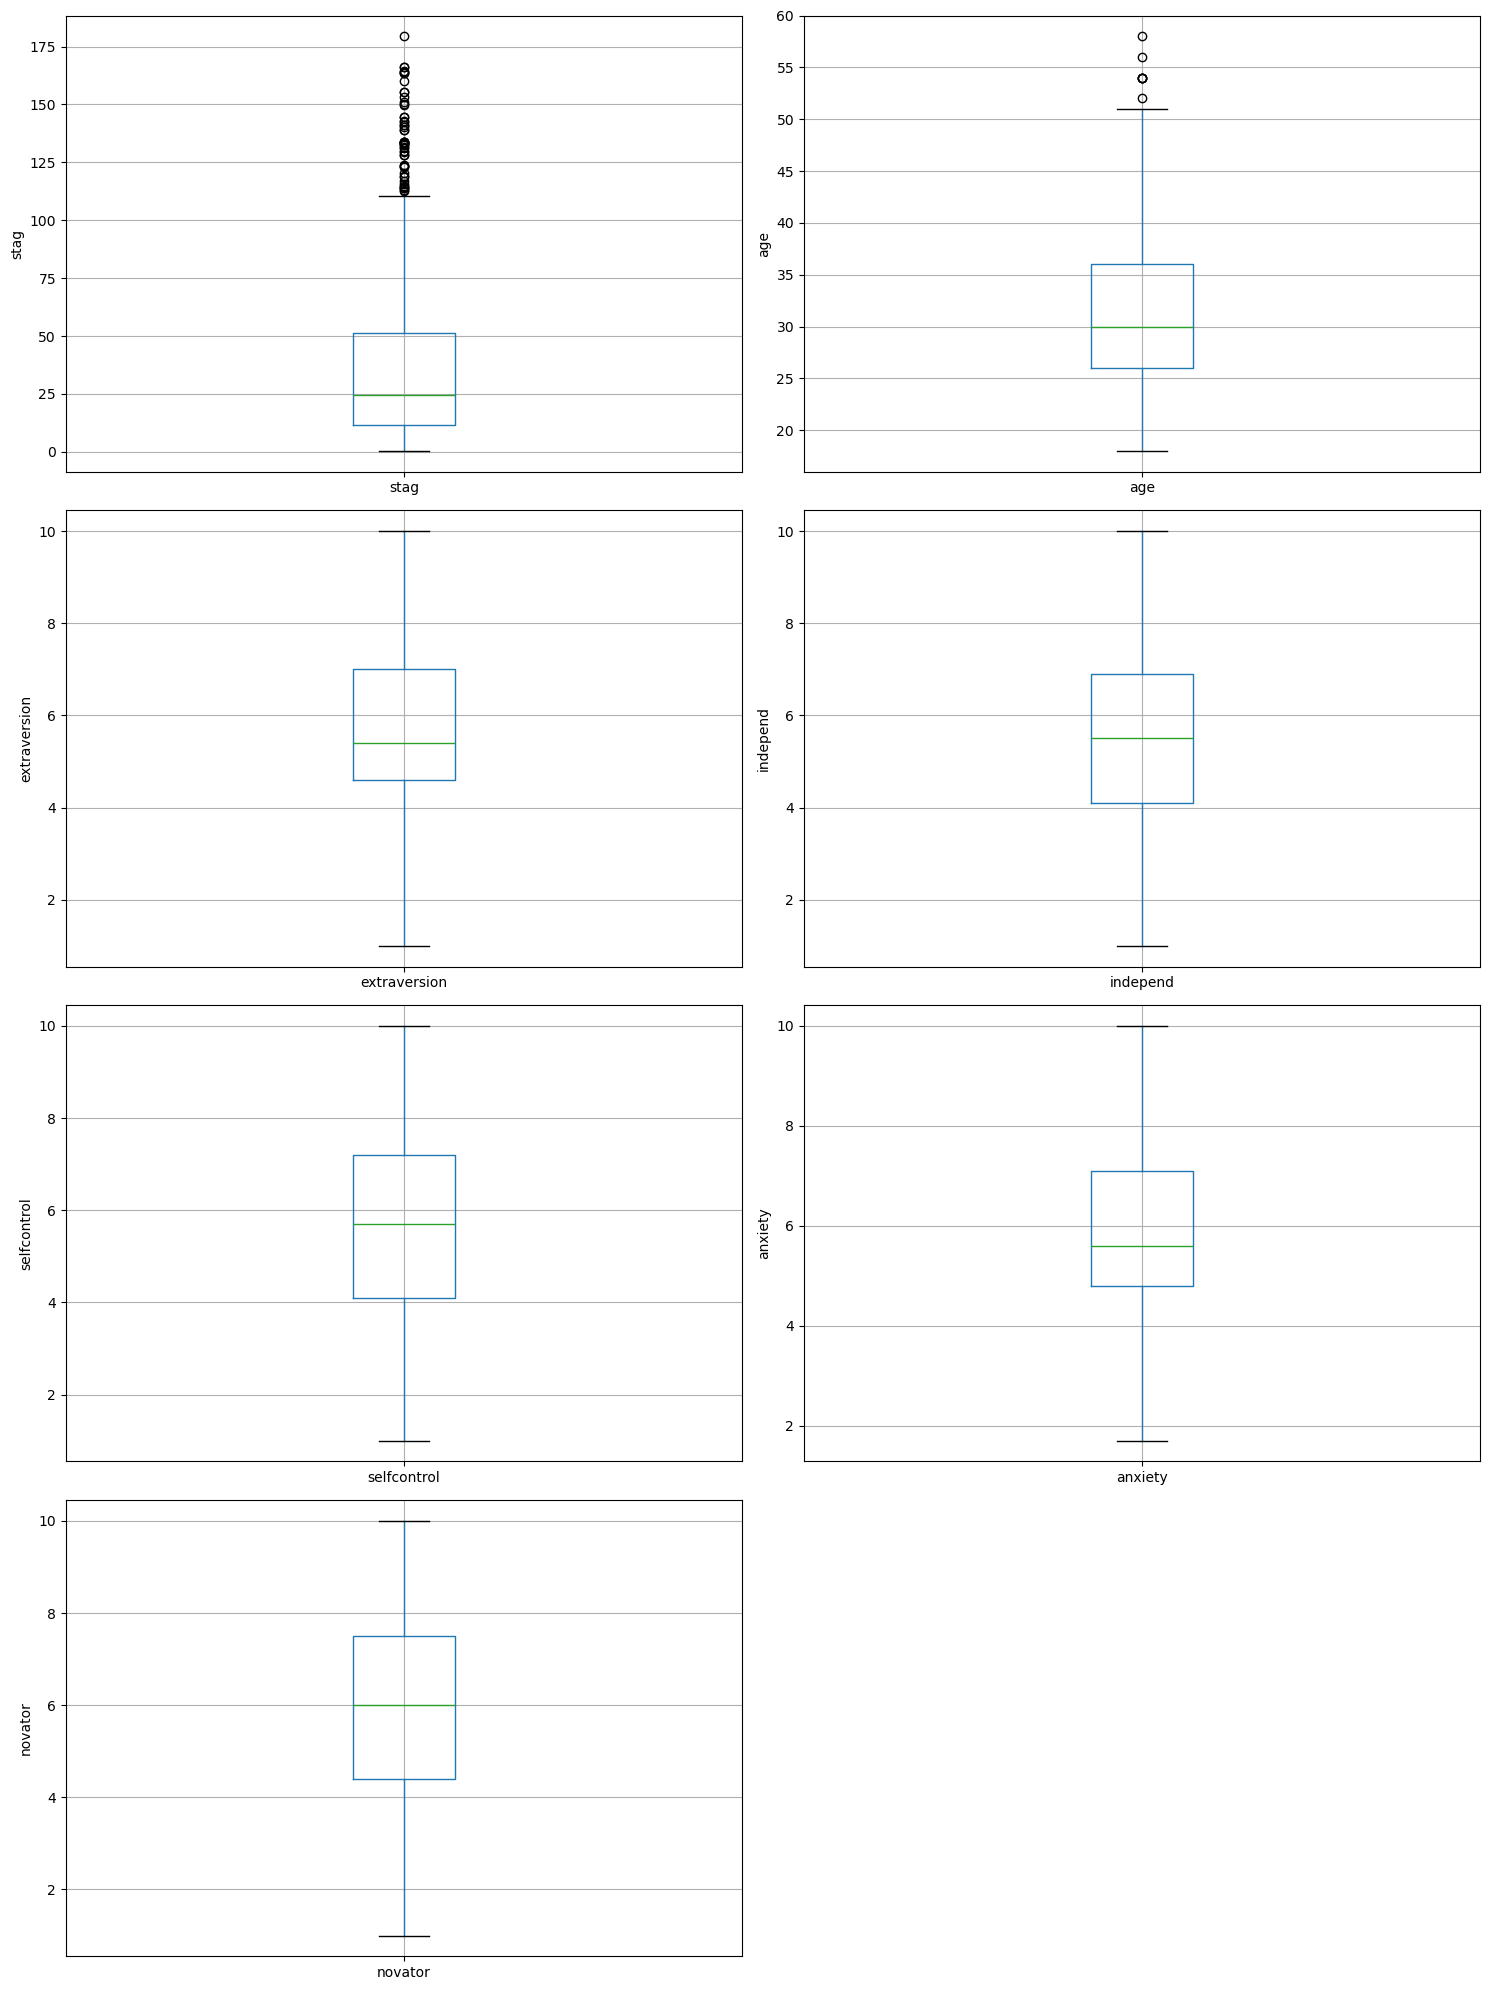

In [582]:
# plot boxplot to identify outliers in numerical variables
# Create a figure with a specified size
plt.figure(figsize=(15, 20))

# List of columns to plot
columns = ['stag', 'age', 'extraversion', 'independ', 'selfcontrol', 'anxiety', 'novator']

# Loop through the columns and create a subplot for each
for i, column in enumerate(columns, 1):
    plt.subplot(4, 2, i)
    fig = df.boxplot(column=column)
    fig.set_title('')
    fig.set_ylabel(column)

# Show the plot
plt.tight_layout()
plt.show()

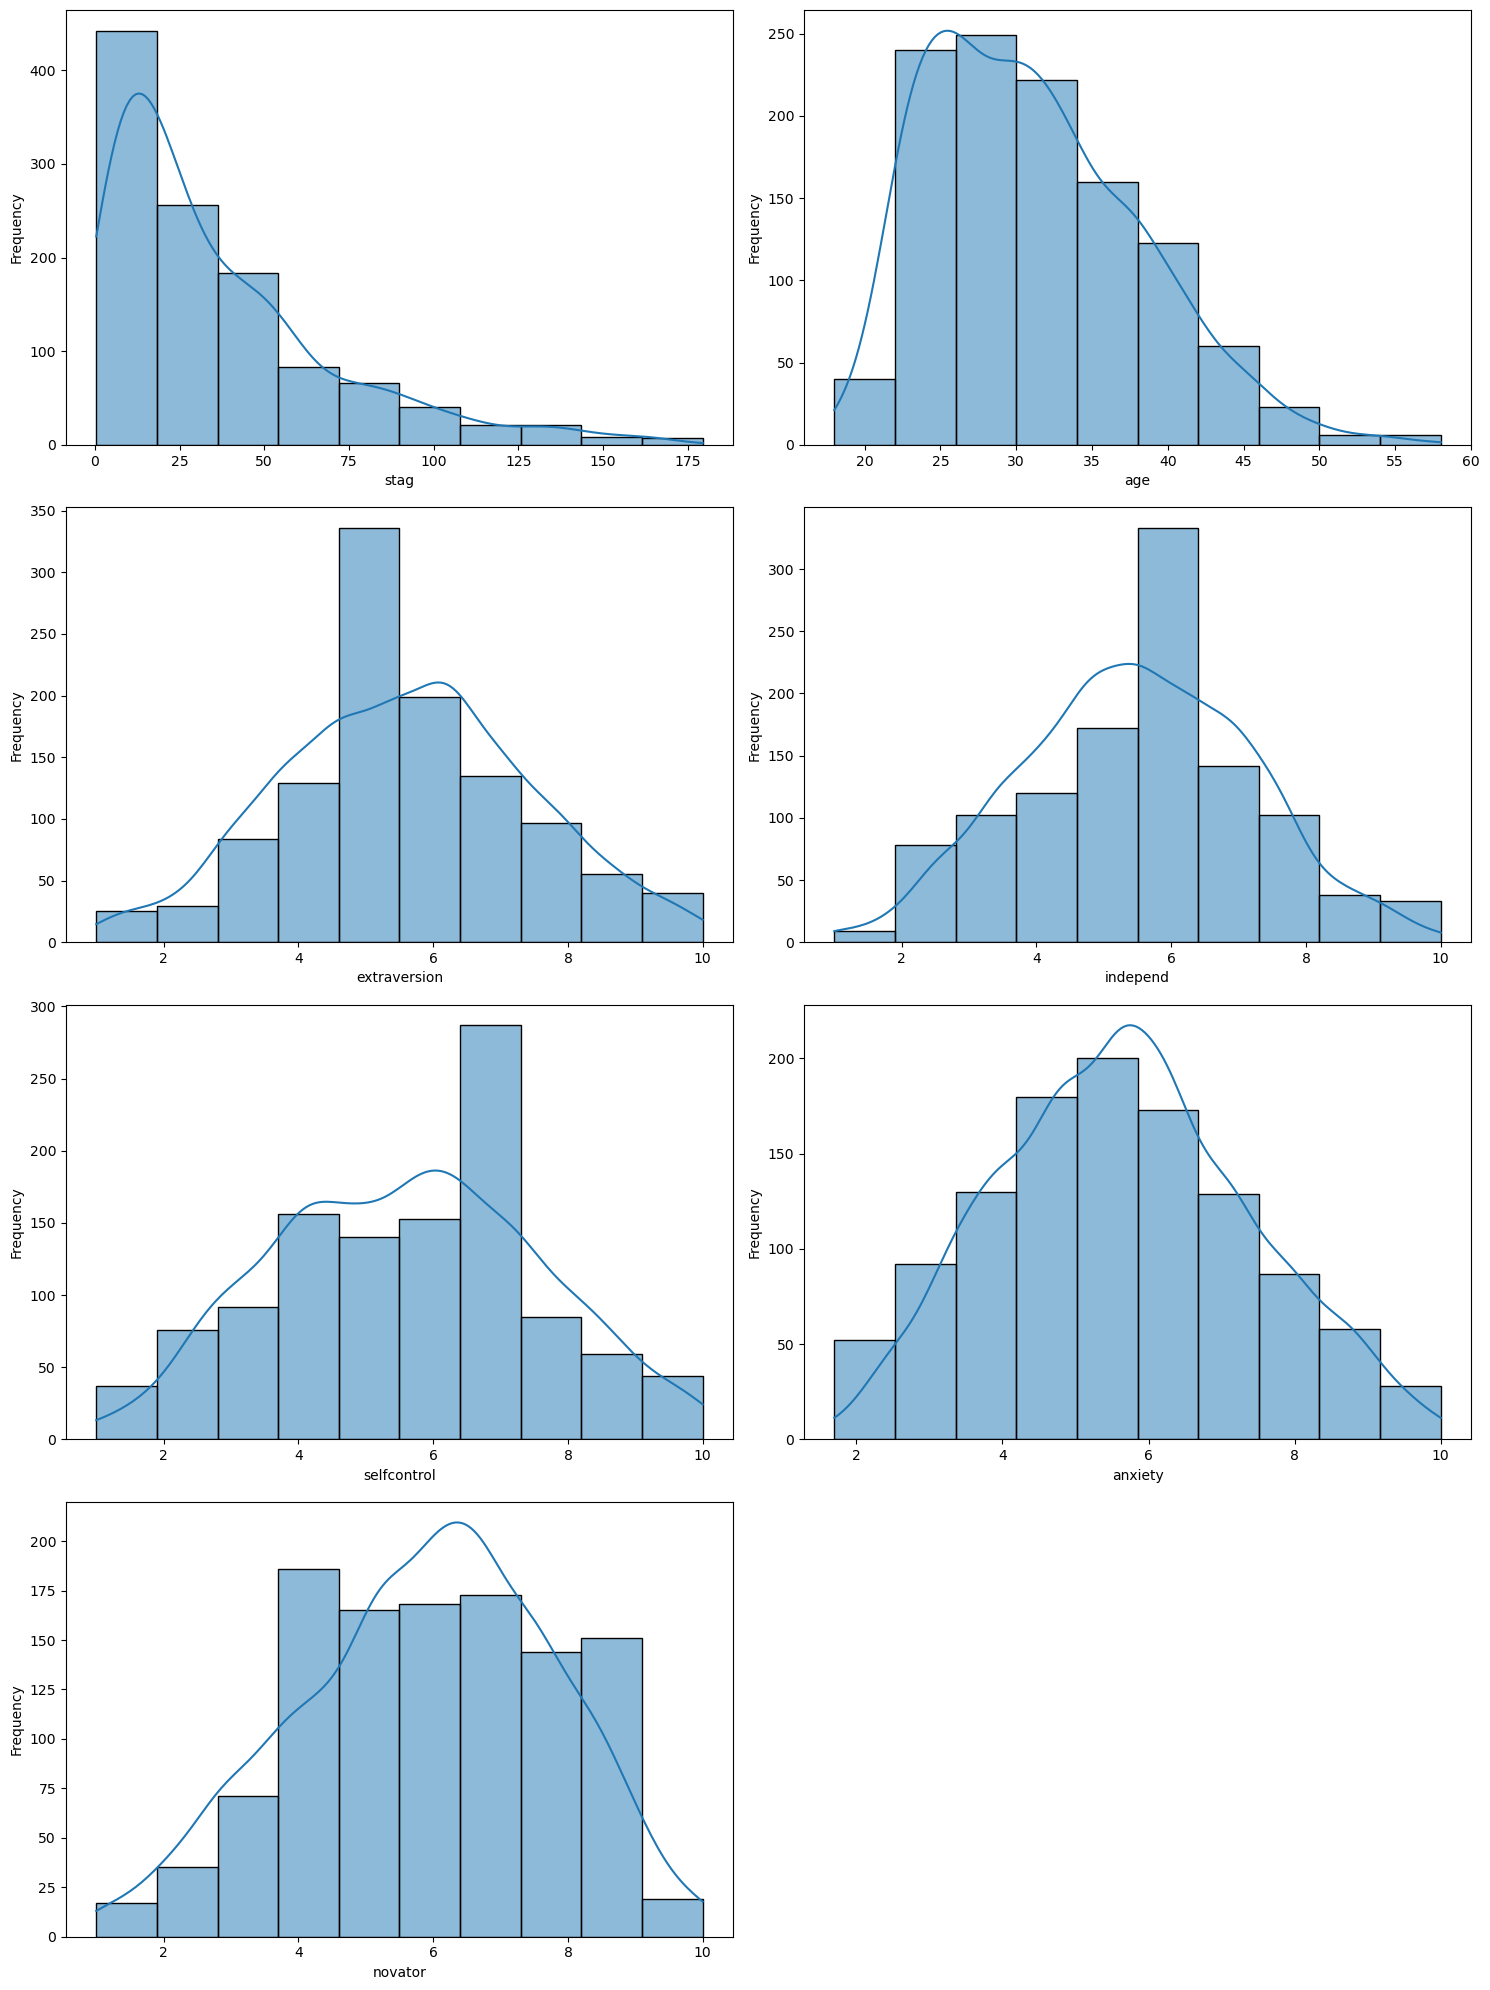

In [583]:
plt.figure(figsize=(15, 20))
columns = ['stag', 'age', 'extraversion', 'independ', 'selfcontrol', 'anxiety', 'novator']

for i, column in enumerate(columns, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[column], bins=10, kde=True)
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [584]:
# find outliers for Stag variable
IQR = df.stag.quantile(0.75) - df.stag.quantile(0.25)
Lower_fence = df.stag.quantile(0.25) - (IQR * 3)
Upper_fence = df.stag.quantile(0.75) + (IQR * 3)
print('Stag outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=Lower_fence,
                                                                               upperboundary=Upper_fence))

Stag outliers are values < -107.03901436999999 or > 170.08624229


In [585]:
# find outliers for Age variable
IQR = df.age.quantile(0.75) - df.age.quantile(0.25)
Lower_fence = df.age.quantile(0.25) - (IQR * 3)
Upper_fence = df.age.quantile(0.75) + (IQR * 3)
print('Age outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=Lower_fence,
                                                                              upperboundary=Upper_fence))

Age outliers are values < -4.0 or > 66.0


<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">4. Declare feature vector and target variable </h3>
</div>


In [586]:
X = df.drop(['event'], axis=1)
y = df['event']

<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">5. Split data into separate training and test set</h3>
</div>


In [587]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)

In [588]:
# check the shape of X_train and X_test
X_train.shape, X_test.shape

((790, 15), (339, 15))

<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">6. Feature Engineering </h3>
</div>


In [589]:
# check data types in X_train
X_train.dtypes

stag            float64
gender           object
age             float64
industry         object
profession       object
traffic          object
coach            object
head_gender      object
greywage         object
way              object
extraversion    float64
independ        float64
selfcontrol     float64
anxiety         float64
novator         float64
dtype: object

In [590]:
# display categorical variables
categorical = [col for col in X_train.columns if X_train[col].dtypes == 'O']
categorical

['gender',
 'industry',
 'profession',
 'traffic',
 'coach',
 'head_gender',
 'greywage',
 'way']

In [591]:
# display numerical variables
numerical = [col for col in X_train.columns if X_train[col].dtypes != 'O']
numerical

['stag',
 'age',
 'extraversion',
 'independ',
 'selfcontrol',
 'anxiety',
 'novator']

<div style="background-color: #e8f4f8; padding: 15px 25px; border-radius: 8px; box-shadow: 0 3px 6px rgba(0, 0, 0, 0.1); border-left: 4px solid #3498db; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h4 style="color: #2c3e50; font-size: 20px; font-weight: bold; margin: 0; padding-bottom: 8px;">6.1. Engineering missing values in numerical variables</h4>
    </div>


In [592]:
# check missing values in numerical variables in X_train
X_train[numerical].isnull().sum()

stag            0
age             0
extraversion    0
independ        0
selfcontrol     0
anxiety         0
novator         0
dtype: int64

In [593]:
# check missing values in numerical variables in X_test
X_test[numerical].isnull().sum()

stag            0
age             0
extraversion    0
independ        0
selfcontrol     0
anxiety         0
novator         0
dtype: int64

<div style="background-color: #e8f4f8; padding: 15px 25px; border-radius: 8px; box-shadow: 0 3px 6px rgba(0, 0, 0, 0.1); border-left: 4px solid #3498db; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h4 style="color: #2c3e50; font-size: 20px; font-weight: bold; margin: 0; padding-bottom: 8px;">6.2. Engineering missing values in categorical variables</h4>
    </div>


In [594]:
# check missing values in X_train categorical variables
X_train[categorical].isnull().mean()

gender         0.0
industry       0.0
profession     0.0
traffic        0.0
coach          0.0
head_gender    0.0
greywage       0.0
way            0.0
dtype: float64

<div style="background-color: #e8f4f8; padding: 15px 25px; border-radius: 8px; box-shadow: 0 3px 6px rgba(0, 0, 0, 0.1); border-left: 4px solid #3498db; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h4 style="color: #2c3e50; font-size: 20px; font-weight: bold; margin: 0; padding-bottom: 8px;">6.3. Engineering outliers in numerical variables</h4>
    </div>


We have seen that the Stag, Age columns contain outliers. I will use top-coding approach to cap maximum values and remove outliers from the above variables.

In [595]:
def max_value(df3, variable, top):
    return np.where(df3[variable] > top, top, df3[variable])


for df3 in [X_train, X_test]:
    df3['stag'] = max_value(df3, 'stag', 170.08624229)
    df3['age'] = max_value(df3, 'age', 66.0)

In [596]:
X_train[['stag', 'age']].max()

stag    166.078029
age      56.000000
dtype: float64

In [597]:
X_test[['stag', 'age']].max()

stag    170.086242
age      58.000000
dtype: float64

In [598]:
X_train[numerical].describe()

,stag,age,extraversion,independ,selfcontrol,anxiety,novator
count,790.000000,790.000000,790.000000,790.000000,790.000000,790.000000,790.000000
mean,34.999880,31.001775,5.583544,5.532911,5.648734,5.606709,5.851013
std,32.722213,6.800167,1.864397,1.709863,2.030238,1.716813,1.893466
min,0.394251,18.000000,1.000000,1.000000,1.000000,1.700000,1.000000
25%,10.858316,26.000000,4.600000,4.100000,4.100000,4.000000,4.400000
50%,23.605749,30.000000,5.400000,5.500000,5.700000,5.600000,6.000000
75%,49.856263,35.000000,7.000000,6.900000,7.200000,7.100000,7.500000
max,166.078029,56.000000,10.000000,10.000000,10.000000,10.000000,10.000000


We can now see that the outliers in stag, age columns are capped.

<div style="background-color: #e8f4f8; padding: 15px 25px; border-radius: 8px; box-shadow: 0 3px 6px rgba(0, 0, 0, 0.1); border-left: 4px solid #3498db; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h4 style="color: #2c3e50; font-size: 20px; font-weight: bold; margin: 0; padding-bottom: 8px;">6.4. Encode categorical variables</h4>
    </div>


In [599]:
X_train[categorical].head()

,gender,industry,profession,traffic,coach,head_gender,greywage,way
983,m,Retail,Sales,referal,no,m,white,car
630,f,Consult,HR,youjs,my head,f,white,bus
688,f,PowerGeneration,HR,youjs,no,m,white,bus
848,m,Retail,Commercial,youjs,no,m,grey,car
1073,m,IT,IT,empjs,my head,m,white,car


In [600]:
# encode categorical variables of X_train
X_train = pd.concat([X_train[numerical],
                     pd.get_dummies(X_train.gender, drop_first=True),
                     pd.get_dummies(X_train.industry, drop_first=True),
                     pd.get_dummies(X_train.profession, drop_first=True),
                     pd.get_dummies(X_train.traffic, drop_first=True),
                     pd.get_dummies(X_train.coach, drop_first=True),
                     pd.get_dummies(X_train.head_gender, drop_first=True),
                     pd.get_dummies(X_train.greywage, drop_first=True),
                     pd.get_dummies(X_train.way, drop_first=True)], axis=1)

In [601]:
X_train.head()

,stag,age,extraversion,independ,selfcontrol,anxiety,novator,m,Agriculture,Banks,...,rabrecNErab,recNErab,referal,youjs,no,yes,m,white,car,foot
983,142.751540,27.0,3.8,6.2,4.1,7.9,5.2,True,False,False,...,False,False,True,False,True,False,True,True,True,False
630,80.492813,25.0,6.2,6.2,5.7,3.3,6.7,False,False,False,...,False,False,False,True,False,False,False,True,False,False
688,42.184805,27.0,3.0,5.5,4.1,7.1,8.3,False,False,False,...,False,False,False,True,True,False,True,True,False,False
848,89.002053,32.0,3.8,3.4,8.7,7.9,4.4,True,False,False,...,False,False,False,True,True,False,True,False,True,False
1073,8.180698,30.0,3.8,5.5,2.6,9.4,3.7,True,False,False,...,False,False,False,False,False,False,True,True,True,False


In [602]:
# encode categorical variables of X_test
X_test = pd.concat([X_test[numerical],
                     pd.get_dummies(X_test.gender, drop_first=True),
                     pd.get_dummies(X_test.industry, drop_first=True),
                     pd.get_dummies(X_test.profession, drop_first=True),
                     pd.get_dummies(X_test.traffic, drop_first=True),
                     pd.get_dummies(X_test.coach, drop_first=True),
                     pd.get_dummies(X_test.head_gender, drop_first=True),
                     pd.get_dummies(X_test.greywage, drop_first=True),
                     pd.get_dummies(X_test.way, drop_first=True)], axis=1)

In [603]:
X_test.head()

,stag,age,extraversion,independ,selfcontrol,anxiety,novator,m,Agriculture,Banks,...,rabrecNErab,recNErab,referal,youjs,no,yes,m,white,car,foot
506,82.825462,23.0,7.0,7.6,3.3,3.3,6.7,False,False,True,...,True,False,False,False,False,True,False,True,True,False
226,94.127310,25.0,6.2,3.4,6.4,6.3,7.5,False,False,False,...,False,False,False,True,True,False,True,False,True,False
641,170.086242,24.0,7.0,4.8,2.6,5.6,8.3,False,False,False,...,False,False,False,False,True,False,False,True,False,False
652,26.874743,26.0,8.6,4.1,4.9,5.6,5.2,False,False,False,...,False,False,False,True,False,False,False,True,False,False
337,29.010267,28.0,9.4,3.4,4.9,3.3,6.0,False,False,False,...,False,False,True,False,True,False,True,True,False,True


In [604]:
X_train.shape, X_test.shape

((790, 50), (339, 50))

<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">7. Feature Scaling</h3>
</div>


In [605]:
X_train.describe()

,stag,age,extraversion,independ,selfcontrol,anxiety,novator
count,790.000000,790.000000,790.000000,790.000000,790.000000,790.000000,790.000000
mean,34.999880,31.001775,5.583544,5.532911,5.648734,5.606709,5.851013
std,32.722213,6.800167,1.864397,1.709863,2.030238,1.716813,1.893466
min,0.394251,18.000000,1.000000,1.000000,1.000000,1.700000,1.000000
25%,10.858316,26.000000,4.600000,4.100000,4.100000,4.000000,4.400000
50%,23.605749,30.000000,5.400000,5.500000,5.700000,5.600000,6.000000
75%,49.856263,35.000000,7.000000,6.900000,7.200000,7.100000,7.500000
max,166.078029,56.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [606]:
cols = X_train.columns

In [607]:
print("Train columns:", X_train.columns)
print("Test columns:", X_test.columns)

Train columns: Index(['stag', 'age', 'extraversion', 'independ', 'selfcontrol', 'anxiety',
       'novator', 'm', 'Agriculture', 'Banks', 'Building', 'Consult', 'IT',
       'Mining', 'Pharma', 'PowerGeneration', 'RealEstate', 'Retail', 'State',
       'Telecom', 'etc', 'manufacture', 'transport', 'BusinessDevelopment',
       'Commercial', 'Consult', 'Engineer', 'Finanñe', 'HR', 'IT', 'Law',
       'Marketing', 'PR', 'Sales', 'Teaching', 'etc', 'manage', 'advert',
       'empjs', 'friends', 'rabrecNErab', 'recNErab', 'referal', 'youjs', 'no',
       'yes', 'm', 'white', 'car', 'foot'],
      dtype='object')
Test columns: Index(['stag', 'age', 'extraversion', 'independ', 'selfcontrol', 'anxiety',
       'novator', 'm', 'Agriculture', 'Banks', 'Building', 'Consult', 'IT',
       'Mining', 'Pharma', 'PowerGeneration', 'RealEstate', 'Retail', 'State',
       'Telecom', 'etc', 'manufacture', 'transport', 'BusinessDevelopment',
       'Commercial', 'Consult', 'Engineer', 'Finanñe', 'HR', 'I

In [608]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [609]:
# restructure or reassign the column names back to the scaled data
X_train = pd.DataFrame(X_train, columns=[cols])

In [610]:
X_test = pd.DataFrame(X_test, columns=[cols])

<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">8. Model training</h3>
</div>


In [611]:
# train a logistic regression model on the training set
from sklearn.linear_model import LogisticRegression

# instantiate the model
logreg = LogisticRegression(solver='liblinear', random_state=0)
# fit the model
logreg.fit(X_train, y_train)

LogisticRegression(random_state=0, solver='liblinear')

<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">8. Predict results </h3>
</div>


In [612]:
y_pred_test = logreg.predict(X_test)
y_pred_test

array([1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,

<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">8. Check accuracy score </h3>
</div>


In [613]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))

Model accuracy score: 0.5988


In [614]:
y_pred_train = logreg.predict(X_train)
y_pred_train

array([1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,

In [615]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.6557


Check for overfitting and underfitting

In [616]:
# print the scores on training and test set
print('Training set score: {:.4f}'.format(logreg.score(X_train, y_train)))
print('Test set score: {:.4f}'.format(logreg.score(X_test, y_test)))

Training set score: 0.6557
Test set score: 0.5988


In [617]:
# fit the Logsitic Regression model with C=100
logreg100 = LogisticRegression(C=100, solver='liblinear', random_state=0)

# fit the model
logreg100.fit(X_train, y_train)

LogisticRegression(C=100, random_state=0, solver='liblinear')

In [618]:
print('Training set score: {:.4f}'.format(logreg.score(X_train, y_train)))
print('Test set score: {:.4f}'.format(logreg.score(X_test, y_test)))

Training set score: 0.6557
Test set score: 0.5988


In [619]:
# fit the Logsitic Regression model with C=100
logreg100 = LogisticRegression(C=0.01, solver='liblinear', random_state=0)

# fit the model
logreg100.fit(X_train, y_train)

LogisticRegression(C=0.01, random_state=0, solver='liblinear')

In [620]:
print('Training set score: {:.4f}'.format(logreg.score(X_train, y_train)))
print('Test set score: {:.4f}'.format(logreg.score(X_test, y_test)))

Training set score: 0.6557
Test set score: 0.5988


In [621]:
# check class distribution in test set

y_test.value_counts()

event
0    176
1    163
Name: count, dtype: int64

In [623]:
# check null accuracy score

null_accuracy = (176/(176+163))

print('Null accuracy score: {0:0.4f}'. format(null_accuracy))

Null accuracy score: 0.5192


<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">8. Confusion matrix</h3>
</div>

In [624]:
# Print the Confusion Matrix and slice it into four pieces
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)
print('Confusion matrix\n\n', cm)
print('\nTrue Positives(TP) = ', cm[0,0])
print('\nTrue Negatives(TN) = ', cm[1,1])
print('\nFalse Positives(FP) = ', cm[0,1])
print('\nFalse Negatives(FN) = ', cm[1,0])

Confusion matrix

 [[105  71]
 [ 65  98]]

True Positives(TP) =  105

True Negatives(TN) =  98

False Positives(FP) =  71

False Negatives(FN) =  65


<Axes: >

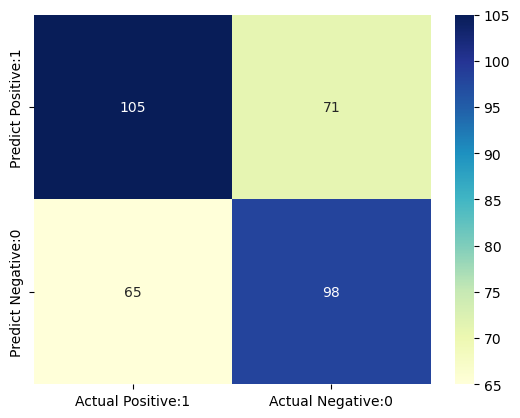

In [625]:
# visualize confusion matrix with seaborn heatmap

cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'],
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')